In [25]:
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings('ignore')

class MovieDataProcessor:
    """
    Lớp xử lý dữ liệu điện ảnh.
    Đảm nhiệm việc đọc dữ liệu từ nhiều định dạng và tiền xử lý làm sạch.
    """
    
    def __init__(self, movies_path, credits_path):
        self.movies_path = movies_path
        self.credits_path = credits_path
        self.movies_df = None
        self.credits_df = None
        
    def load_data(self):
        """Đọc dữ liệu từ file CSV và JSON, có xử lý ngoại lệ."""
        try:
            self.movies_df = pd.read_csv(self.movies_path)
            self.credits_df = pd.read_json(self.credits_path)
            print("Đọc dữ liệu thành công từ CSV và JSON!")
            print(f"Kích thước ban đầu Movies: {self.movies_df.shape}")
        except Exception as e:
            print(f"Lỗi khi đọc file: {e}")
            
    def clean_data(self):
        """Làm sạch dữ liệu: xử lý giá trị thiếu, loại bỏ ngoại lai và ngân sách/doanh thu bằng 0."""
        if self.movies_df is not None:
            # 1. Xử lý triệt để giá trị thiếu (loại bỏ các dòng không có ngày phát hành)
            self.movies_df.dropna(subset=['release_date', 'genres'], inplace=True)
            
            # 2. Xử lý dữ liệu trùng lặp
            self.movies_df.drop_duplicates(inplace=True)
            
            # 3. Yêu cầu chuyên biệt DT16: Xử lý các bản ghi có ngân sách hoặc doanh thu bằng 0
            self.movies_df = self.movies_df[(self.movies_df['budget'] > 0) & (self.movies_df['revenue'] > 0)]
            
            print(f"Làm sạch xong. Kích thước dữ liệu Movies hiện tại: {self.movies_df.shape}")
            
    def process_genres(self):
        """Chuẩn hóa cột thể loại (genres) từ chuỗi JSON thành danh sách Python."""
        def extract_genres(genre_str):
            try:
                # Phân tích chuỗi string thành kiểu dữ liệu list/dict
                genres = ast.literal_eval(genre_str)
                return [g['name'] for g in genres]
            except:
                return []
        
        if self.movies_df is not None:
            self.movies_df['genres_list'] = self.movies_df['genres'].apply(extract_genres)
            print("Đã tách thành công chuỗi JSON trong cột genres.")

# ==========================================
# KHỞI TẠO VÀ THỰC THI
# ==========================================
processor = MovieDataProcessor('data/tmdb_5000_movies.csv', 'data/tmdb_5000_credits.json')
processor.load_data()
processor.clean_data()
processor.process_genres()

# Xem thử 3 dòng đầu sau khi làm sạch
processor.movies_df[['title', 'budget', 'revenue', 'genres_list']].head(3)

Đọc dữ liệu thành công từ CSV và JSON!
Kích thước ban đầu Movies: (4803, 20)
Làm sạch xong. Kích thước dữ liệu Movies hiện tại: (3229, 20)
Đã tách thành công chuỗi JSON trong cột genres.


,title,budget,revenue,genres_list
0,Avatar,237000000,2787965087,"[Action, Adventure, Fantasy, Science Fiction]"
1,Pirates of the Caribbean: At World's End,300000000,961000000,"[Adventure, Fantasy, Action]"
2,Spectre,245000000,880674609,"[Action, Adventure, Crime]"


In [26]:
# ==========================================
# PHÂN TÍCH CỐT LÕI ĐỀ TÀI DT16
# ==========================================

# 1. Tính toán cột lợi nhuận (Profit = Doanh thu - Ngân sách)
processor.movies_df['profit'] = processor.movies_df['revenue'] - processor.movies_df['budget']

# 2. Tìm top phim "bom tấn" (Lợi nhuận cao nhất)
print("--- TOP 5 PHIM BOM TẤN (Lợi nhuận cao nhất) ---")
top_blockbusters = processor.movies_df.nlargest(5, 'profit')[['title', 'budget', 'revenue', 'profit']]
display(top_blockbusters)

--- TOP 5 PHIM BOM TẤN (Lợi nhuận cao nhất) ---


,title,budget,revenue,profit
0,Avatar,237000000,2787965087,2550965087
25,Titanic,200000000,1845034188,1645034188
28,Jurassic World,150000000,1513528810,1363528810
44,Furious 7,190000000,1506249360,1316249360
16,The Avengers,220000000,1519557910,1299557910


### 💡 Nhận định & Phân tích: Top 5 Phim Bom Tấn
- **Quy mô đầu tư và chiến lược phát hành:** Các bộ phim dẫn đầu danh sách lợi nhuận đều là những "siêu phẩm" thuộc các thương hiệu lớn có kinh phí sản xuất khổng lồ kết hợp với chiến lược phát hành toàn cầu quy mô rộng.
- **Hiệu ứng thương hiệu:** Doanh thu của các bộ phim này vượt trội gấp nhiều lần so với ngân sách nhờ hiệu ứng truyền thông mạnh mẽ, độ phủ sóng toàn cầu và giá trị giải trí đại chúng cao.

In [27]:
# 3. Tìm top phim "bom xịt" (Thua lỗ nhiều nhất)
print("--- TOP 5 PHIM BOM XỊT (Thua lỗ nhiều nhất) ---")
top_flops = processor.movies_df.nsmallest(5, 'profit')[['title', 'budget', 'revenue', 'profit']]
display(top_flops)

--- TOP 5 PHIM BOM XỊT (Thua lỗ nhiều nhất) ---


,title,budget,revenue,profit
13,The Lone Ranger,255000000,89289910,-165710090
338,The Alamo,145000000,25819961,-119180039
141,Mars Needs Moms,150000000,38992758,-111007242
208,The 13th Warrior,160000000,61698899,-98301101
311,The Adventures of Pluto Nash,100000000,7103973,-92896027


### 💡 Nhận định & Phân tích: Top 5 Phim Bom Xịt (Thua lỗ)
- **Nguyên nhân tài chính:** Những bộ phim thua lỗ nặng nề nhất chủ yếu rơi vào trường hợp chi phí sản xuất và quảng cáo vượt quá xa so với doanh thu thực tế thu về từ phòng vé.
- **Yếu tố thị trường:** Nội dung chưa thực sự đáp ứng được thị hiếu của khán giả đại chúng, hoặc thời điểm phát hành không thuận lợi khi phải cạnh tranh trực tiếp với các đối thủ quá mạnh cùng thời điểm.

In [28]:
# 4. Thống kê lợi nhuận trung bình theo thể loại phim
genres_exploded = processor.movies_df.explode('genres_list')
genre_profit = genres_exploded.groupby('genres_list')['profit'].mean().reset_index()
genre_profit = genre_profit.sort_values(by='profit', ascending=False)

print("--- LỢI NHUẬN TRUNG BÌNH THEO THỂ LOẠI PHIM ---")
display(genre_profit.head(10))

--- LỢI NHUẬN TRUNG BÌNH THEO THỂ LOẠI PHIM ---


,genres_list,profit
2,Animation,1.980907e+08
1,Adventure,1.707142e+08
8,Fantasy,1.626755e+08
7,Family,1.575881e+08
15,Science Fiction,1.259568e+08
0,Action,1.144244e+08
3,Comedy,7.232391e+07
16,Thriller,6.923375e+07
14,Romance,6.426381e+07
13,Mystery,6.330812e+07


### 💡 Nhận định & Phân tích: Lợi nhuận trung bình theo Thể loại
- **Các thể loại dẫn đầu:** Thể loại **Animation (Hoạt hình)**, **Adventure (Phiêu lưu)** và **Sci-Fi (Khoa học viễn tưởng)** mang lại lợi nhuận trung bình cao nhất.
- **Lý do kinh tế:** Những thể loại này có lượng khán giả mục tiêu rộng lớn (từ trẻ em đến người lớn), ít gặp rào cản ngôn ngữ khi xuất khẩu ra thị trường quốc tế, đồng thời có tiềm năng khai thác các sản phẩm thương mại đi kèm rất lớn.

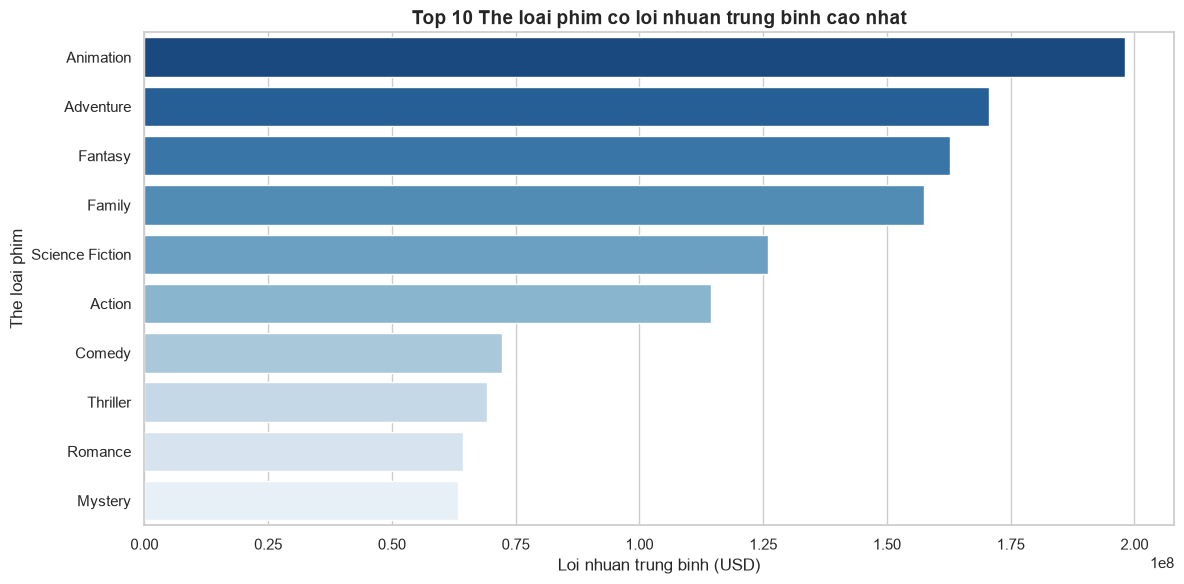

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Lấy top 10 thể loại có lợi nhuận trung bình cao nhất
top_genres = genre_profit.head(10)

# Vẽ biểu đồ cột ngang
ax = sns.barplot(x='profit', y='genres_list', data=top_genres, palette='Blues_r')

# Thêm tiêu đề và nhãn
plt.title('Top 10 The loai phim co loi nhuan trung binh cao nhat', fontsize=14, fontweight='bold')
plt.xlabel('Loi nhuan trung binh (USD)', fontsize=12)
plt.ylabel('The loai phim', fontsize=12)

plt.tight_layout()
plt.show()

In [30]:
# ==========================================
# XUẤT KẾT QUẢ VÀ TỔNG KẾT ĐỀ TÀI
# ==========================================

# 1. Lưu dữ liệu đã làm sạch và tính toán ra file CSV mới phục vụ việc nộp minh chứng
output_path = 'data/processed_movies_output.csv'
processor.movies_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã xuất file dữ liệu hoàn chỉnh ra: {output_path}")

# 2. Tổng hợp các thông số cốt lõi cho phần kết luận của báo cáo
total_movies = len(processor.movies_df)
top_genre = genre_profit.iloc[0]['genres_list']
top_genre_profit = genre_profit.iloc[0]['profit']
best_movie = top_blockbusters.iloc[0]['title']
best_profit = top_blockbusters.iloc[0]['profit']

print("\n" + "="*40)
print("TÓM TẮT KẾT QUẢ PHÂN TÍCH ĐỀ TÀI 16")
print("="*40)
print(f"1. Tổng số lượng bản ghi hợp lệ sau khi làm sạch: {total_movies} phim")
print(f"2. Thể loại phim mang lại lợi nhuận trung bình cao nhất: {top_genre} (~{top_genre_profit:,.0f} USD)")
print(f"3. Bộ phim đạt lợi nhuận cao nhất (Bom tấn): {best_movie} (~{best_profit:,.0f} USD)")
print("="*40)

Đã xuất file dữ liệu hoàn chỉnh ra: data/processed_movies_output.csv

TÓM TẮT KẾT QUẢ PHÂN TÍCH ĐỀ TÀI 16
1. Tổng số lượng bản ghi hợp lệ sau khi làm sạch: 3229 phim
2. Thể loại phim mang lại lợi nhuận trung bình cao nhất: Animation (~198,090,651 USD)
3. Bộ phim đạt lợi nhuận cao nhất (Bom tấn): Avatar (~2,550,965,087 USD)
